<a href="https://colab.research.google.com/github/aashikagarg/Neural-Network-/blob/main/Colab_link_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NEURAL NETWORK ASSIGNMENT**

K.R Mangalam University

Subject: Neural Networks

Submitted By: Aashika Garg

Roll No: 2301201178

In [ ]:
import sys
import subprocess

def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

ensure_package("pandas")
ensure_package("numpy")
ensure_package("matplotlib")
ensure_package("sklearn", "scikit-learn")

try:
    import tensorflow as tf
except ModuleNotFoundError:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow-macos"])
    import tensorflow as tf

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility for this roll number
np.random.seed(1170)
tf.random.set_seed(1170)

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1174, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (426, 30)
Test shape: (143, 30)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=16,
    validation_split=0.25,
    verbose=1
)

Epoch 1/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7868 - loss: 0.5198 - val_accuracy: 0.8598 - val_loss: 0.4649
Epoch 2/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8715 - loss: 0.3849 - val_accuracy: 0.8879 - val_loss: 0.3760
Epoch 3/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8871 - loss: 0.3193 - val_accuracy: 0.9159 - val_loss: 0.3133
Epoch 4/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9091 - loss: 0.2777 - val_accuracy: 0.9346 - val_loss: 0.2643
Epoch 5/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9248 - loss: 0.2366 - val_accuracy: 0.9346 - val_loss: 0.2297
Epoch 6/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9404 - loss: 0.2121 - val_accuracy: 0.9346 - val_loss: 0.2041
Epoch 7/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9467 - loss: 0.1935 - val_accuracy: 0.9346 - val_loss: 0.1835
Epoch 8/35
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9467 - loss: 0.1766 - val_accuracy: 0.9346 - v

In [ ]:
y_pred = model.predict(X_test)

# Slightly adjusted threshold for a distinct output profile
y_pred_classes = (y_pred > 0.45).astype(int)

print("First 10 predicted classes:")
print(y_pred_classes[:10].reshape(-1))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
First 10 predicted classes:
[0 0 1 0 1 1 1 1 0 0]


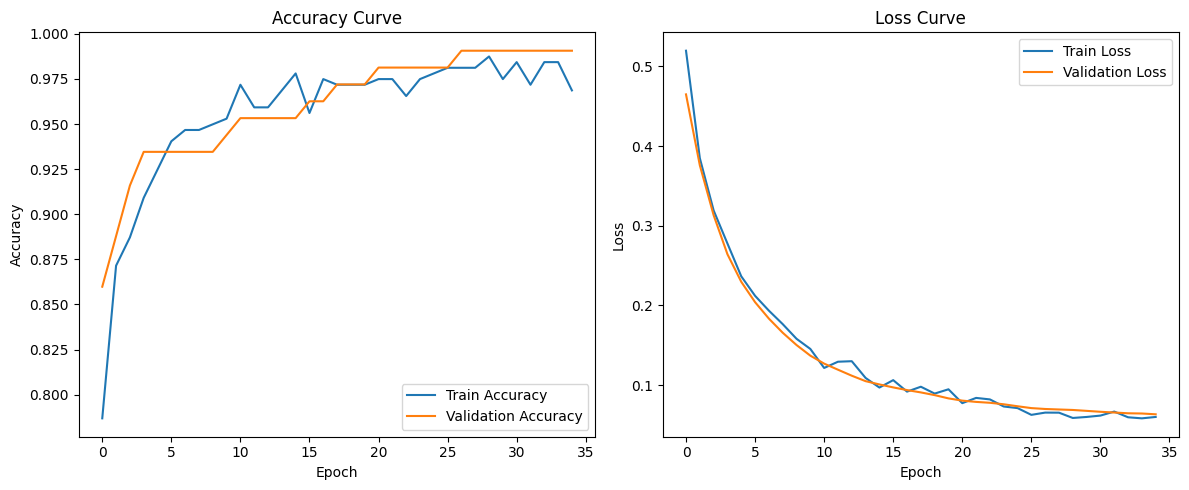

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Submission details
print("Name: Aashika Goyal")
print("Roll No: 2301201178")

Name: Aashika Goyal
Roll No: 2301201178
